# DATASET: Butterfly classificaton

### 31 de mayo de 2026

En el siguiente notebook (creado en Google Colab), se podrá observar el proceso de exportación de datos de un dataset de imágenes proveniente de kaggle, la utilización de archivos CSV para entrenar un modelo ML de clasificación, aumentar la cantidad de imágenes por medio de modificaciones para incrementar la precisión del modelo, y preprocesamiento.

En este caso, se está utilizando un dataset que clasifica mariposas.

In [130]:
import os
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#### Descargar dataset de Butterfly Image Classification
En este bloque se descarga el dataset desde Kaggle.

Cable aclarar que el dataset ya está separado en train y test, contando con directorios diferentes correspondientes a cada uno de los conjuntos. Se importa directamente desde kaggle; cuenta con archivos JPG de las imágenes de las mariposas.

Además, tiene dos archivos de tipo CSV; uno de entrenamiento y uno de pruebas. El CSV de entrenamiento contiene el nombre del archivo y el tipo de mariposa que es. A partir de ahí, se entrena al modelo.

### Obtener información desde el CSV de Training_set.csv

El dataset contiene un CSV llamado Training_set.csv donde viene el nombre del archivo junto con la clasificación de la mariposa. Se utilizarán estos datos para entrenar al modelo.

In [106]:
data_csv = pd.read_csv("Training_set.csv")

data_csv.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [213]:
from sklearn.model_selection import train_test_split

# Separar el archivo CSV del dataset en 70% entrenamiento y 30% testing
train_csv, test_csv = train_test_split(data_csv, test_size=0.3, random_state=54, stratify=data_csv['label'])

len(train_csv)


4549

In [214]:

len(test_csv)

1950

In [215]:
CLASSES_PER_PLOT = 15

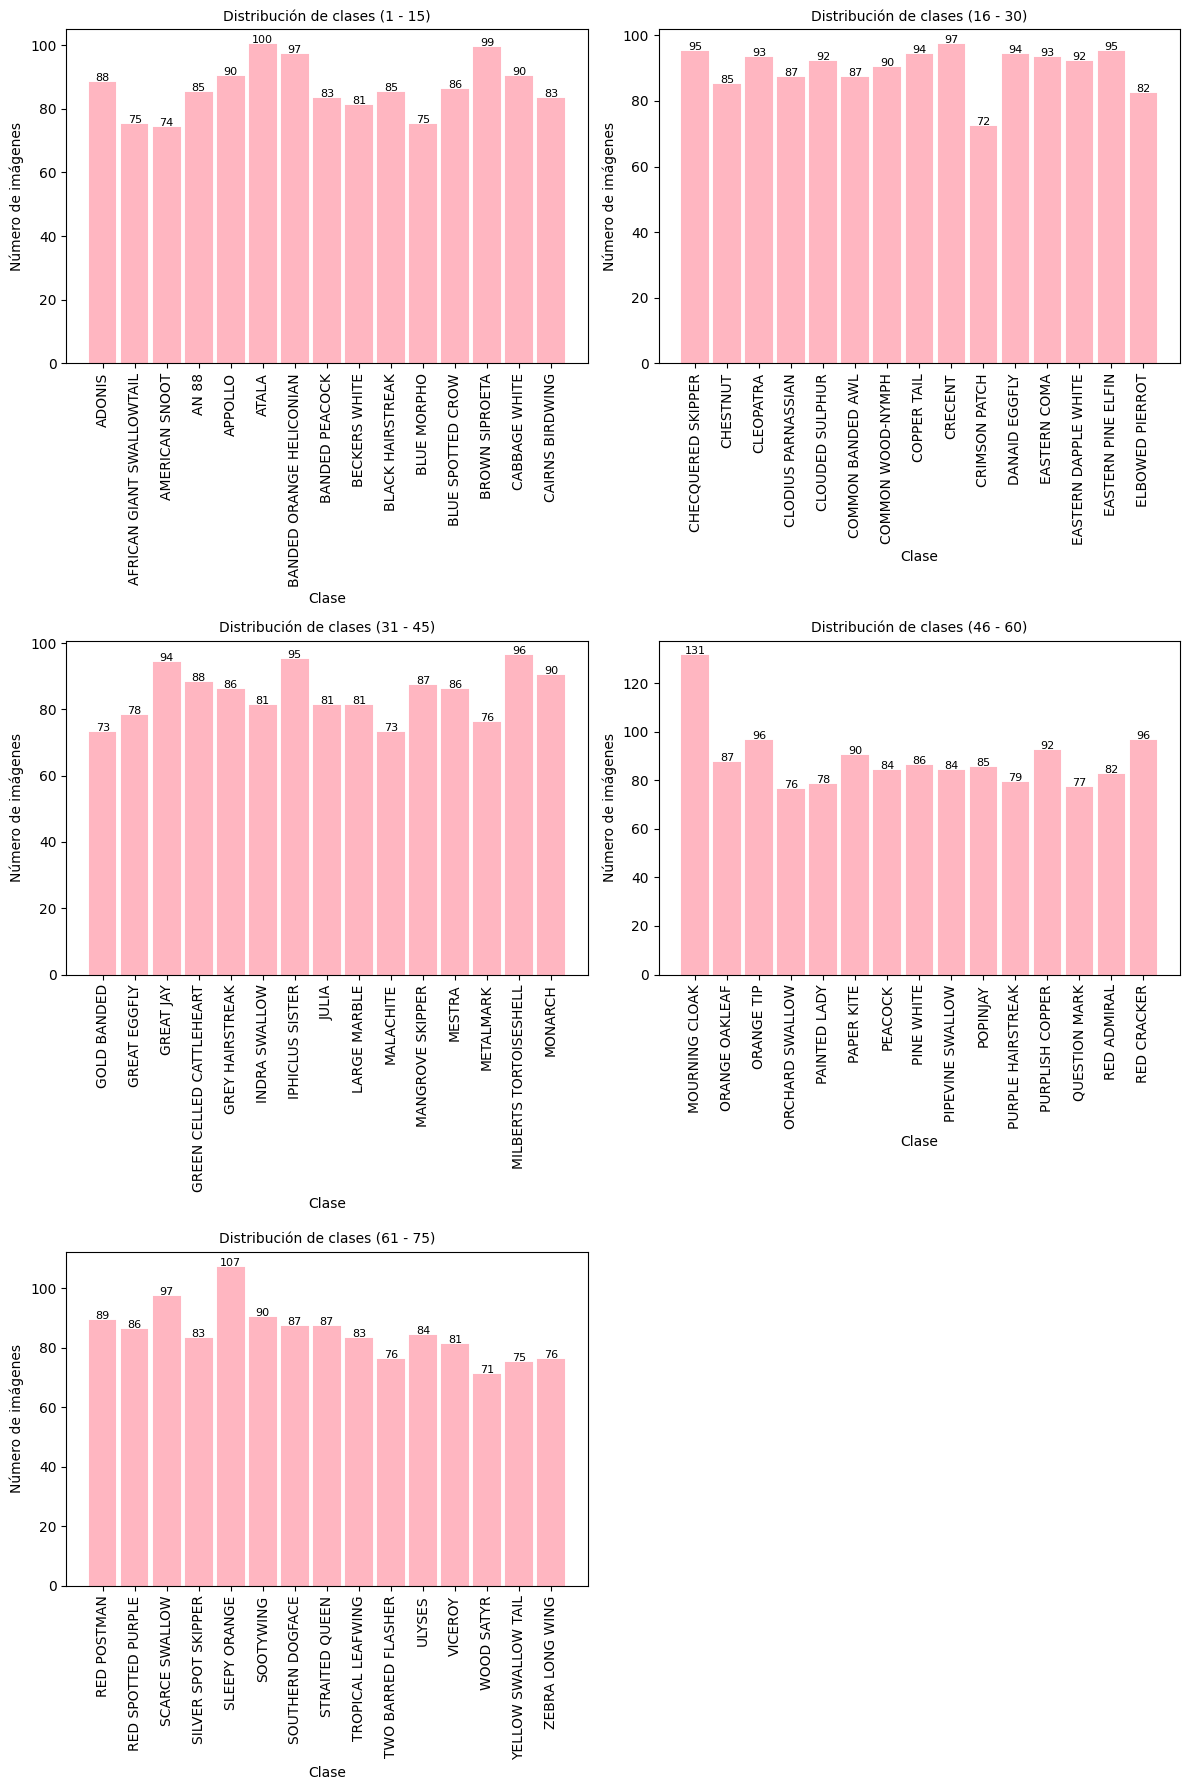

In [237]:
class_counts = data_csv['label'].value_counts().sort_index()


fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.flatten()

for plot_idx, start in enumerate(range(0, len(class_counts), CLASSES_PER_PLOT)):
    subset = class_counts.iloc[start:start+CLASSES_PER_PLOT]

    ax = axes[plot_idx]
    
    bars = ax.bar(
        subset.index,
        subset.values,
        color='lightpink',
        edgecolor='lightpink',
        linewidth=1.5
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_title(
        f'Distribución de clases ({start+1} - {start+len(subset)})',
        fontsize=10,
        fontweight='light'
    )

    ax.set_xlabel('Clase')
    ax.set_ylabel('Número de imágenes')
    
    ax.tick_params(axis='x', rotation=90)



axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [109]:
train_csv["filepath"] = train_csv["filename"].apply(

    lambda x: os.path.join("train", x)

)

train_csv

,filename,label,filepath
47,Image_48.jpg,BANDED PEACOCK,train/Image_48.jpg
100,Image_101.jpg,BECKERS WHITE,train/Image_101.jpg
1758,Image_1759.jpg,LARGE MARBLE,train/Image_1759.jpg
5647,Image_5648.jpg,CLOUDED SULPHUR,train/Image_5648.jpg
5602,Image_5603.jpg,ZEBRA LONG WING,train/Image_5603.jpg
...,...,...,...
4988,Image_4989.jpg,GREAT JAY,train/Image_4989.jpg
2383,Image_2384.jpg,BANDED ORANGE HELICONIAN,train/Image_2384.jpg
4705,Image_4706.jpg,CLODIUS PARNASSIAN,train/Image_4706.jpg
3046,Image_3047.jpg,CLODIUS PARNASSIAN,train/Image_3047.jpg


In [110]:
test_csv["filepath"] = test_csv["filename"].apply(
    lambda x: os.path.join("train", x)
)
test_csv.head()

,filename,label,filepath
806,Image_807.jpg,CRIMSON PATCH,train/Image_807.jpg
446,Image_447.jpg,SOOTYWING,train/Image_447.jpg
1628,Image_1629.jpg,COPPER TAIL,train/Image_1629.jpg
3721,Image_3722.jpg,CLODIUS PARNASSIAN,train/Image_3722.jpg
3148,Image_3149.jpg,GREAT JAY,train/Image_3149.jpg


### Llevar a cabo la augmentation
En esta sección, se lleva a cabo la aumentación de datos. Se utiliza el comando ImageDataGenerator importado de tensorflow, y se generan las imágenes nuevas a partir del mismo.

In [111]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Se generan las imágenes con los parámetros de modificación especificados
train_datagen = ImageDataGenerator(
    rescale = 1./255, # convierte los valores de los pixeles a un número entre 0-1
    rotation_range = 10, # rango de grados para rotar la imagen
    width_shift_range = 0.2, # rango de porcentaje para incrementar el ancho
    height_shift_range = 0.2, # rango de porcentaje para incrementar la altura
    shear_range = 0.3, # rango de % aplicar transformaciones de deformación
    zoom_range = 0.3, # rango de % para aplicar transformaciones de zoom
    horizontal_flip = True,
    validation_split = 0.2 # Allocate 20% of the training data for validation
)

In [112]:
IMG_SIZE = (75, 75)

In [113]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_csv,
    x_col="filepath", # path del archivo
    y_col="label",
    target_size = IMG_SIZE,
    batch_size = 8,
    class_mode='categorical', # ya que son múltiples categorías
    subset='training'
  )

images, labels = train_generator[0]

# Se obtiene el objeto de los índicies de las clases
# a partir de lo que se generó en train_generator
class_indices = train_generator.class_indices

# DataFrame para visualizar las clases posibles
class_indices_df = pd.DataFrame.from_dict(class_indices, orient='index', columns=['Number'])

class_indices_df



Found 3640 validated image filenames belonging to 75 classes.


,Number
ADONIS,0
AFRICAN GIANT SWALLOWTAIL,1
AMERICAN SNOOT,2
AN 88,3
APPOLLO,4
...,...
ULYSES,70
VICEROY,71
WOOD SATYR,72
YELLOW SWALLOW TAIL,73


In [114]:
val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_csv,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)

Found 909 validated image filenames belonging to 75 classes.


In [115]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_csv,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size = 8,
    class_mode='categorical',
    shuffle=False
)

print(f"Number of test images: {test_generator.samples}")

Found 1950 validated image filenames belonging to 75 classes.
Number of test images: 1950


### Visualización
Se imprimen las imágenes generadas para la aumentación junto con el tipo de mariposa que son.

<Figure size 640x480 with 0 Axes>

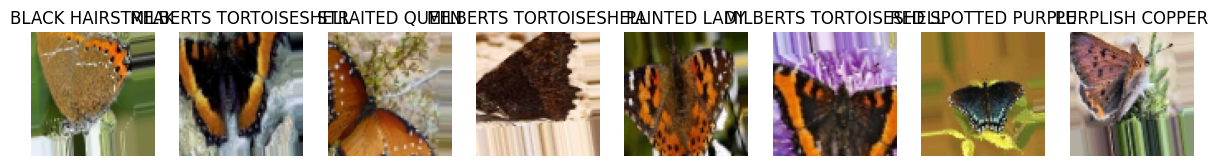

<Figure size 640x480 with 0 Axes>

In [116]:
# Se voltea el orden del diccionario class_indices para que sea
# índice: valor en lugar de valor: índice
idx_to_class = {v: k for k, v in class_indices.items()}

f, axarr = plt.subplots(1, images.shape[0], figsize=(15, 4))

for i in range(images.shape[0]):
  axarr[i].imshow(images[i])
  class_index = labels[i].argmax()
  class_name = idx_to_class[class_index]
  axarr[i].set_title(class_name) # configurar el nombr de la clase de mariposa
  axarr[i].axis("off")

plt.figure()

### CNN para el modelo de análisis

In [200]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

In [207]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint

num_classes = len(class_indices)

model = models.Sequential()

model.add(base_model)

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))

# Activación softmax en vez de sigmoid porque existen múltiples clases
model.add(layers.Dense(num_classes, activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=1e-6),
						metrics=['acc'])

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,346,603 (85.25 MB)

 Trainable params: 22,312,171 (85.11 MB)

 Non-trainable params: 34,432 (134.50 KB)

### Entrenamiento del modelo
Se ejecuta el entrenamiento del modelo (en este caso únicamente en una época) y se grafica utilizando matplotlib para generar dos gráficos; uno que muestre la evolución del valor de accuracy y otro que muestra la evolución de loss.

Cuando existen más épocas hay mayor cantidad de puntos que muestran cómo evoluciona el entrenamiento del modelo; si sube el loss o baja, si el accuracy incrementa, etc.

In [202]:
checkpoint_filepath = 'checkpoints/butterfly_model.keras'

# print(f"Model loaded successfully from: {checkpoint_filepath}")
loaded_model.summary()

In [208]:
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

In [209]:
import os

os.path.exists(checkpoint_filepath)

True

In [211]:
loaded_model = tf.keras.models.load_model(checkpoint_filepath)

In [212]:
history = loaded_model.fit(
	train_generator,
	validation_data = val_generator,
	epochs = 1, # Épocas
  callbacks=[model_checkpoint]
)


455/455 ━━━━━━━━━━━━━━━━━━━━ 78s 154ms/step - acc: 0.7736 - loss: 0.8175 - val_acc: 0.7723 - val_loss: 3.3178


In [171]:
history2 = loaded_model.fit(
	train_generator,
	validation_data = val_generator,
	epochs = 25, # Épocas
  callbacks=[model_checkpoint]
)

Epoch 1/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 49s 106ms/step - acc: 0.5387 - loss: 2.4736 - val_acc: 0.5919 - val_loss: 2.6767
Epoch 2/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 52s 114ms/step - acc: 0.5503 - loss: 2.4270 - val_acc: 0.5798 - val_loss: 3.3905
Epoch 3/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 54s 119ms/step - acc: 0.5717 - loss: 2.3301 - val_acc: 0.6073 - val_loss: 2.9664
Epoch 4/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - acc: 0.5934 - loss: 2.2547 - val_acc: 0.6205 - val_loss: 2.8498
Epoch 5/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 62s 137ms/step - acc: 0.5951 - loss: 2.1918 - val_acc: 0.6150 - val_loss: 3.6783
Epoch 6/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 60s 131ms/step - acc: 0.5874 - loss: 2.1785 - val_acc: 0.6436 - val_loss: 3.2573
Epoch 7/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 61s 134ms/step - acc: 0.6038 - loss: 2.1084 - val_acc: 0.6348 - val_loss: 2.9462
Epoch 8/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 61s 134ms/step - acc: 0.6093 - loss: 2.0553 - val_acc: 0.6403 - val_loss: 2.7751
Epoch 9/25
455/455 ━━━━━━━━━━━━━

In [172]:
history3 = loaded_model.fit(
	train_generator,
	validation_data = val_generator,
	epochs = 25, # Épocas
  callbacks=[model_checkpoint]
)

Epoch 1/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 50s 109ms/step - acc: 0.6802 - loss: 1.4216 - val_acc: 0.6920 - val_loss: 3.1819
Epoch 2/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 54s 119ms/step - acc: 0.6860 - loss: 1.4085 - val_acc: 0.7173 - val_loss: 2.8836
Epoch 3/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - acc: 0.6967 - loss: 1.3795 - val_acc: 0.7129 - val_loss: 2.9093
Epoch 4/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - acc: 0.6953 - loss: 1.3786 - val_acc: 0.7437 - val_loss: 2.6540
Epoch 5/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 57s 125ms/step - acc: 0.6970 - loss: 1.3524 - val_acc: 0.7261 - val_loss: 2.9761
Epoch 6/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - acc: 0.7080 - loss: 1.3011 - val_acc: 0.7085 - val_loss: 3.0867
Epoch 7/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 57s 125ms/step - acc: 0.6898 - loss: 1.3376 - val_acc: 0.7107 - val_loss: 3.3557
Epoch 8/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - acc: 0.7027 - loss: 1.3095 - val_acc: 0.7371 - val_loss: 3.3346
Epoch 9/25
455/455 ━━━━━━━━━━━━━

In [191]:
history4 = loaded_model.fit(
	train_generator,
	validation_data = val_generator,
	epochs = 50, # Épocas
  callbacks=[model_checkpoint]
)

Epoch 1/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - acc: 0.7448 - loss: 0.9331

/Users/emiliodiaz/tf-env/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:329: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


455/455 ━━━━━━━━━━━━━━━━━━━━ 51s 112ms/step - acc: 0.7503 - loss: 0.9148 - val_acc: 0.7734 - val_loss: 2.9683
Epoch 2/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 55s 120ms/step - acc: 0.7643 - loss: 0.9070 - val_acc: 0.7855 - val_loss: 3.2632
Epoch 3/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 55s 121ms/step - acc: 0.7541 - loss: 0.9339 - val_acc: 0.7800 - val_loss: 2.5904
Epoch 4/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - acc: 0.7511 - loss: 0.9362 - val_acc: 0.7679 - val_loss: 3.3384
Epoch 5/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - acc: 0.7500 - loss: 0.9130 - val_acc: 0.7789 - val_loss: 2.4749
Epoch 6/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 59s 129ms/step - acc: 0.7596 - loss: 0.9131 - val_acc: 0.7635 - val_loss: 3.6664
Epoch 7/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 59s 129ms/step - acc: 0.7560 - loss: 0.8859 - val_acc: 0.7580 - val_loss: 2.9159
Epoch 8/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 62s 136ms/step - acc: 0.7456 - loss: 0.9361 - val_acc: 0.7811 - val_loss: 2.9473
Epoch 9/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 64s

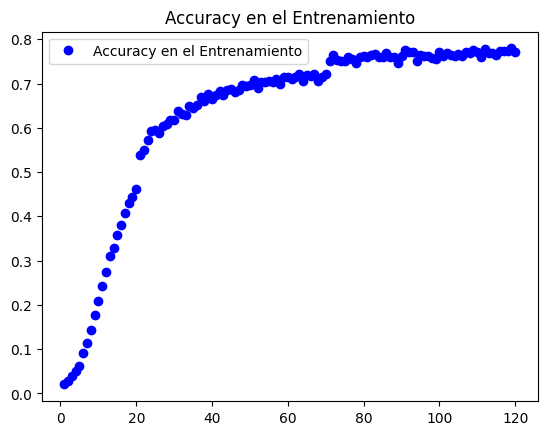

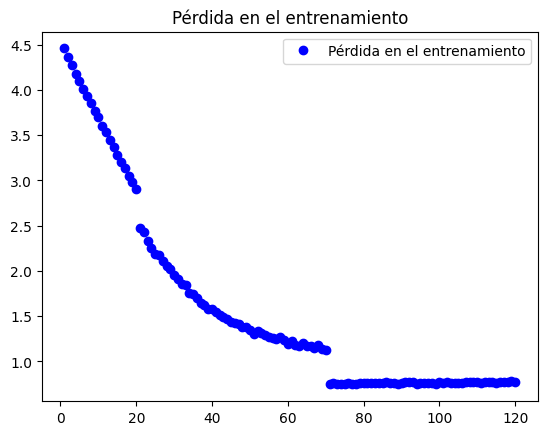

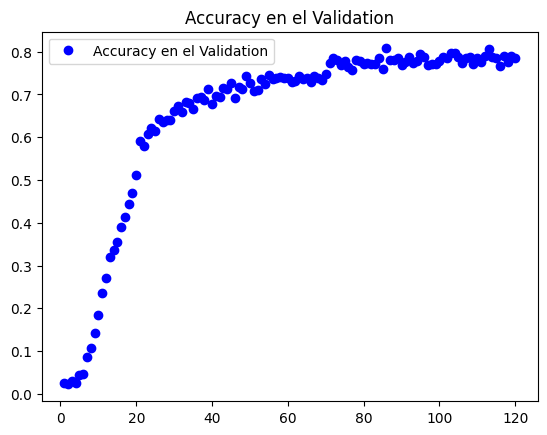

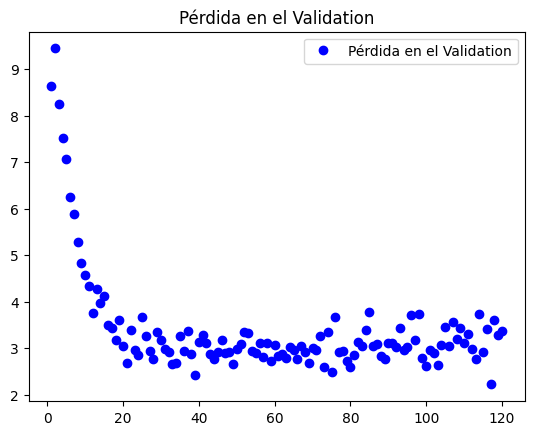

In [192]:
acc = history.history['acc'] + history2.history['acc'] + history3.history['acc'] + history4.history['acc']
loss = history.history['loss'] + history2.history['loss'] + history3.history['loss'] + history4.history['acc']
val = history.history['val_acc'] + history2.history['val_acc'] + history3.history['val_acc'] + history4.history['val_acc']
val_loss = history.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss'] + history4.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='Accuracy en el Entrenamiento')
plt.title('Accuracy en el Entrenamiento')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='Pérdida en el entrenamiento')
plt.title('Pérdida en el entrenamiento')
plt.legend()

plt.show()

plt.plot(epochs,val,'bo',label='Accuracy en el Validation')
plt.title('Accuracy en el Validation')
plt.legend()

plt.figure()

plt.plot(epochs,val_loss, 'bo', label ='Pérdida en el Validation')
plt.title('Pérdida en el Validation')
plt.legend()

plt.show()

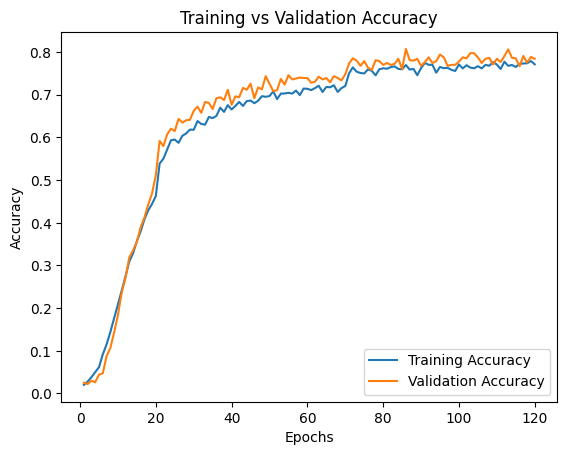

In [193]:
plt.figure()

plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

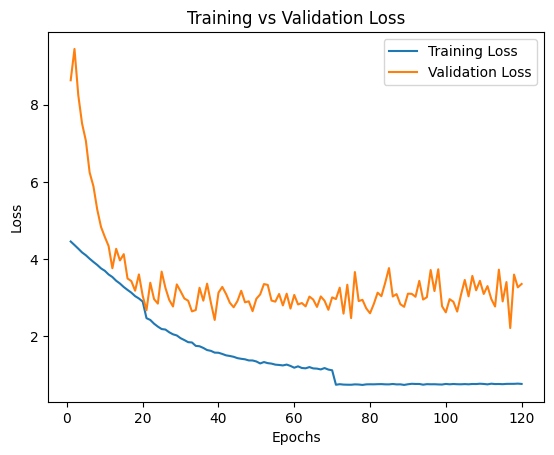

In [194]:
plt.figure()

plt.plot(epochs, loss, label='Training Loss')

plt.plot(epochs, val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

### Evaluación del modelo
Ahora, evaluaremos el modelo entrenado utilizando el conjunto de datos de prueba (`test_generator`) para determinar su rendimiento en datos no vistos.

In [195]:
test_loss, test_acc = loaded_model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - acc: 0.7492 - loss: 3.0893
Test accuracy: 0.7492307424545288
Test loss: 3.0892603397369385


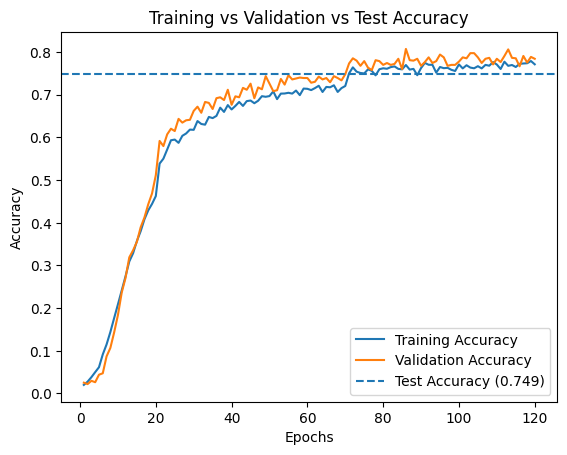

In [196]:
plt.figure()

plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val, label='Validation Accuracy')

plt.axhline(

    y=test_acc,
    linestyle='--',
    label=f'Test Accuracy ({test_acc:.3f})'

)

plt.title('Training vs Validation vs Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### Matriz de Confusión
Ahora, generaremos una matriz de confusión para visualizar el rendimiento del modelo en cada clase. Esto nos permitirá identificar qué clases el modelo clasifica correctamente y cuáles confunde.

In [197]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the model on the test set
predictions = loaded_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)


244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step


In [198]:
true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

### Matrices de Confusión Divididas
Para una mejor visualización, dividiremos la matriz de confusión completa en sub-matrices, mostrando 15 clases en cada una.

<Figure size 1500x1500 with 0 Axes>

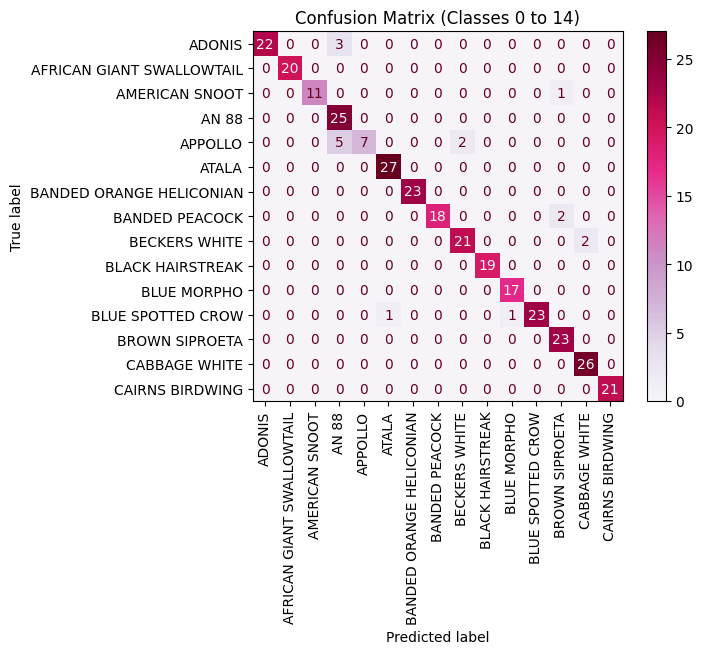

<Figure size 1500x1500 with 0 Axes>

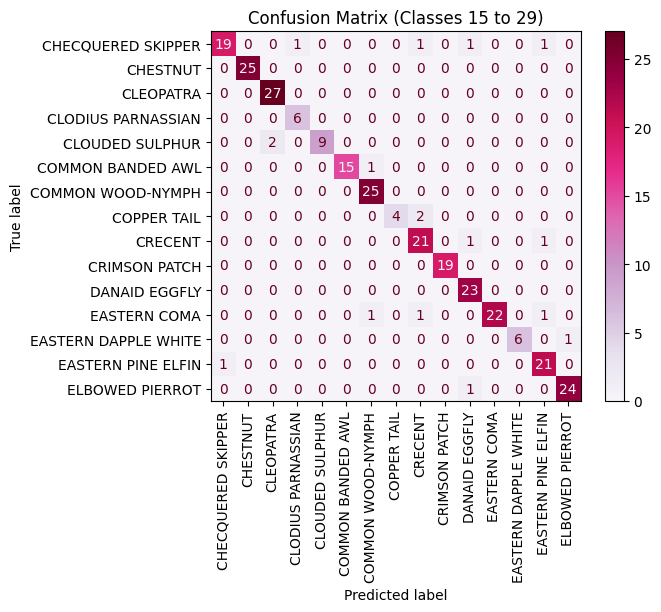

<Figure size 1500x1500 with 0 Axes>

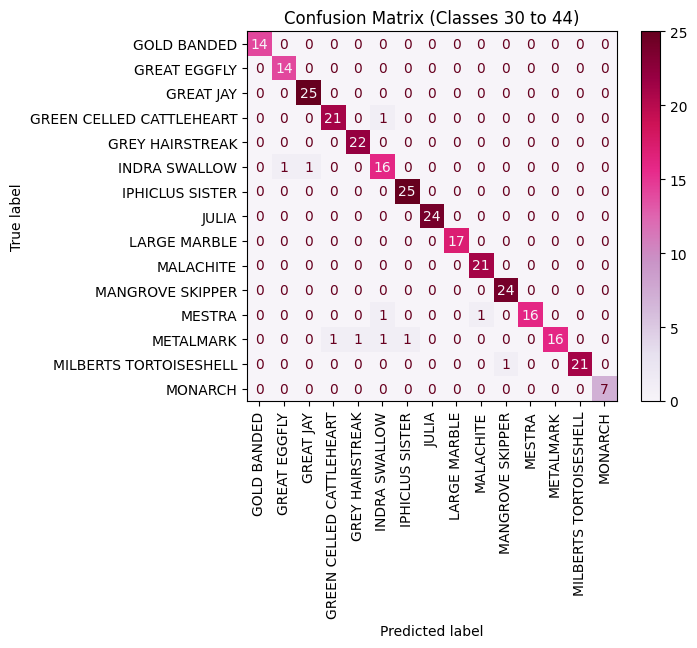

<Figure size 1500x1500 with 0 Axes>

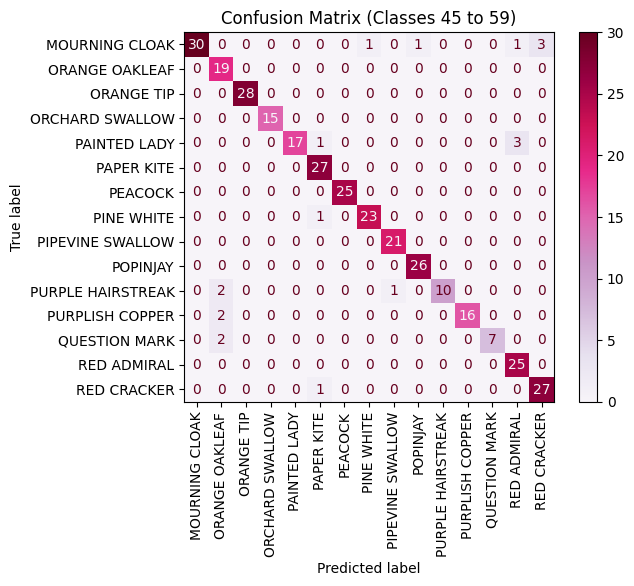

<Figure size 1500x1500 with 0 Axes>

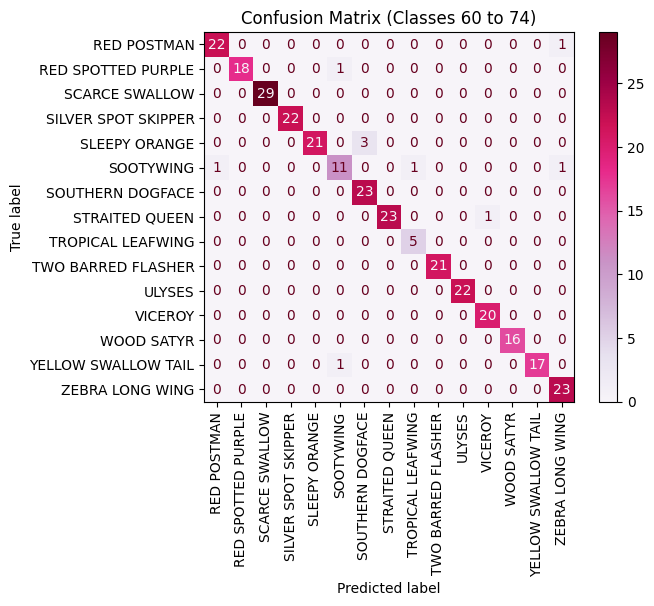

In [199]:
classes_per_matrix = 15

num_sub_matrices = (len(class_labels) + classes_per_matrix - 1) // classes_per_matrix

for i in range(num_sub_matrices):
    start_index = i * classes_per_matrix
    end_index = min((i + 1) * classes_per_matrix, len(class_labels))

    sub_class_labels = class_labels[start_index:end_index]

    sub_cm = cm[start_index:end_index, start_index:end_index]

    plt.figure(figsize=(15, 15))
    disp = ConfusionMatrixDisplay(confusion_matrix=sub_cm, display_labels=sub_class_labels)
    disp.plot(cmap=plt.cm.PuRd, xticks_rotation='vertical')
    plt.title(f'Confusion Matrix (Classes {start_index} to {end_index-1})')
    plt.show()